<a href="https://colab.research.google.com/github/Akashr24/Github/blob/main/lab_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

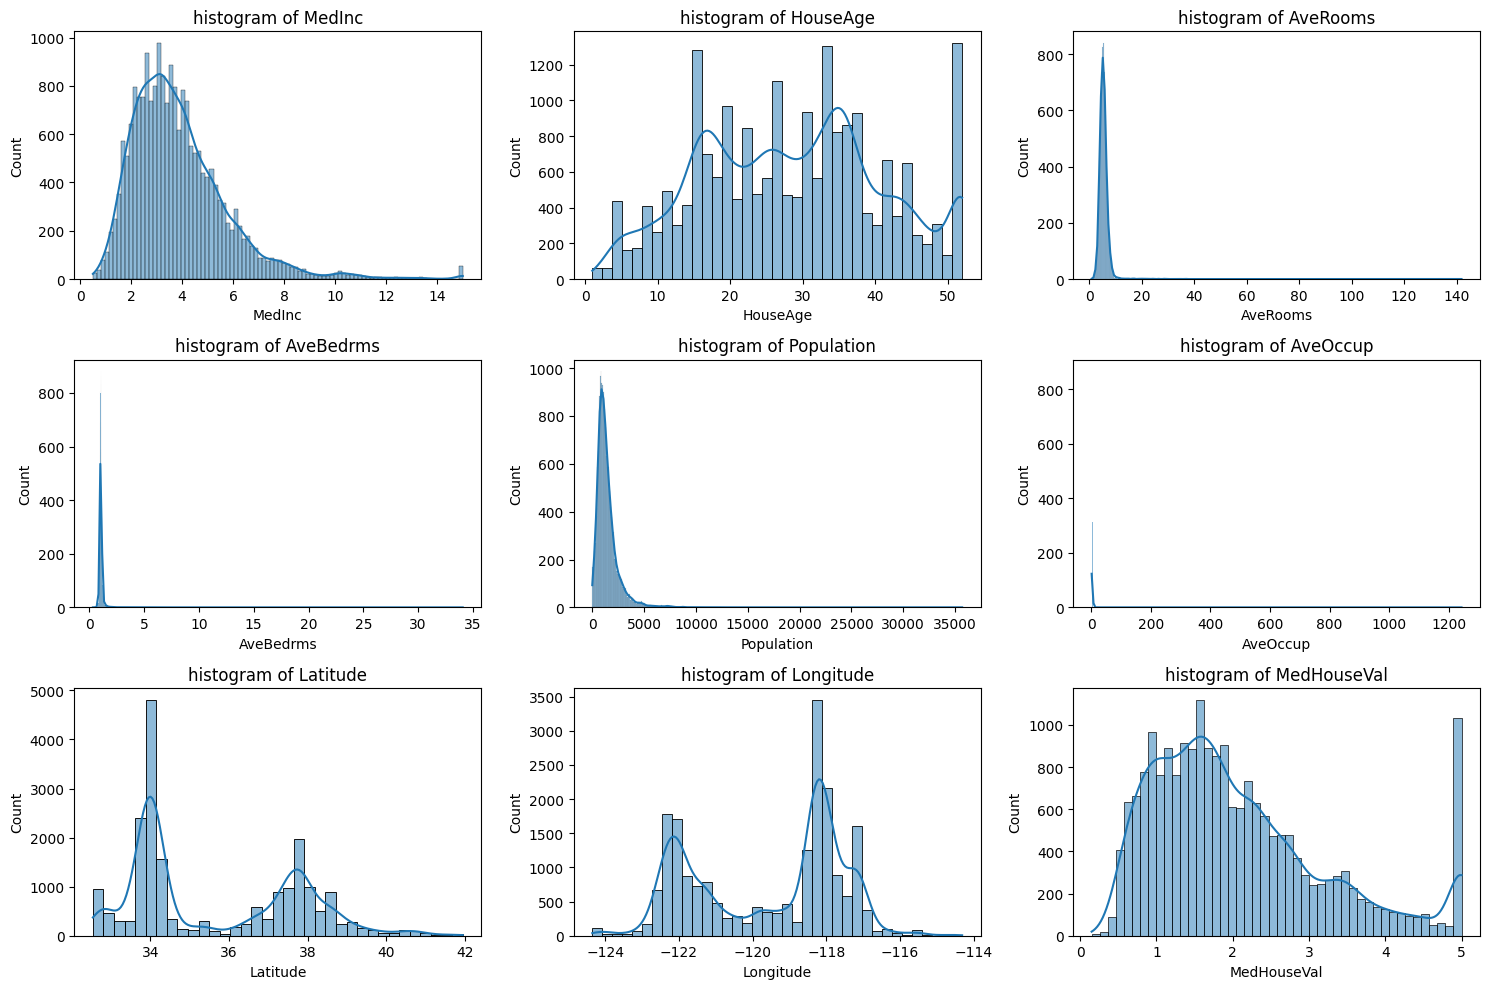

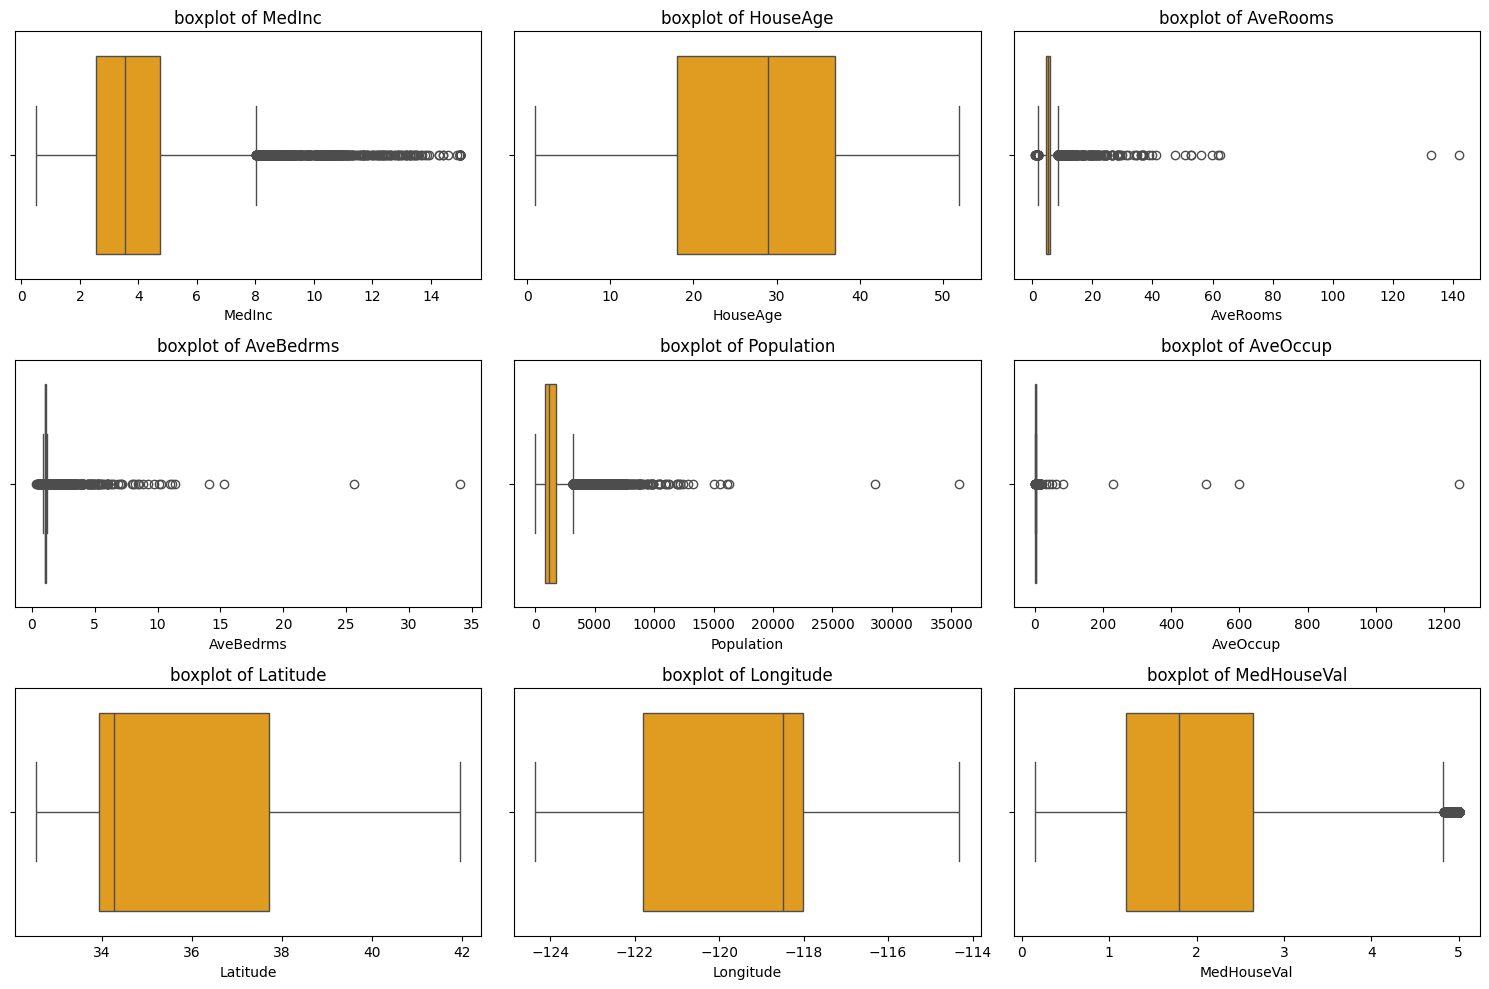

Outliers Detection:
Number of outliers in MedInc: 681
Number of outliers in HouseAge: 0
Number of outliers in AveRooms: 511
Number of outliers in AveBedrms: 1424
Number of outliers in Population: 1196
Number of outliers in AveOccup: 711
Number of outliers in Latitude: 0
Number of outliers in Longitude: 0
Number of outliers in MedHouseVal: 1071
{'MedInc': 681, 'HouseAge': 0, 'AveRooms': 511, 'AveBedrms': 1424, 'Population': 1196, 'AveOccup': 711, 'Latitude': 0, 'Longitude': 0, 'MedHouseVal': 1071}

Dataset Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%   

In [3]:
#lab-1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing(as_frame=True)
housing_df=data.frame
numarical_features=housing_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(15,10))
for i,feature in enumerate(numarical_features):
  plt.subplot(3,3,i+1)
  sns.histplot(housing_df[feature], kde=True) # Changed distplot to histplot and added kde=True for density curve
  plt.title(f'histogram of {feature}')
plt.tight_layout()
plt.show()
plt.figure(figsize=(15,10))
for i,feature in enumerate(numarical_features):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=housing_df[feature],color='orange')
  plt.title(f'boxplot of {feature}')
plt.tight_layout()
plt.show()
print('Outliers Detection:')
outliers_summary = {}
for feature in numarical_features:
  Q1=housing_df[feature].quantile(0.25)
  Q3=housing_df[feature].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  outliers=housing_df[(housing_df[feature]<lower_bound) | (housing_df[feature]>upper_bound)]
  outliers_summary[feature] = len(outliers)
  print(f"Number of outliers in {feature}: {len(outliers)}")
print(outliers_summary)
print("\nDataset Summary:")
print(housing_df.describe())

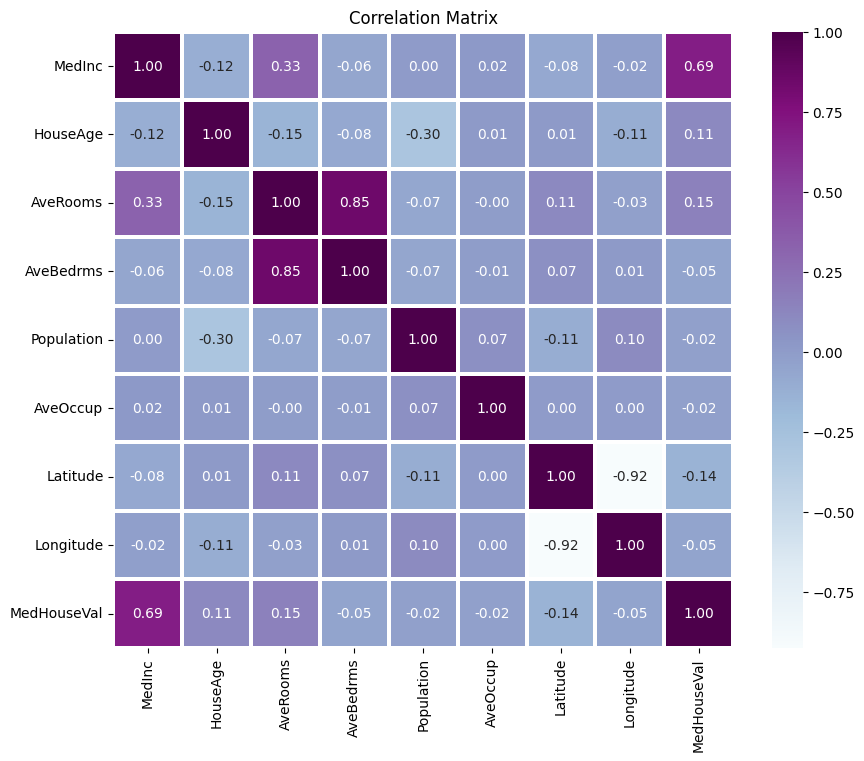

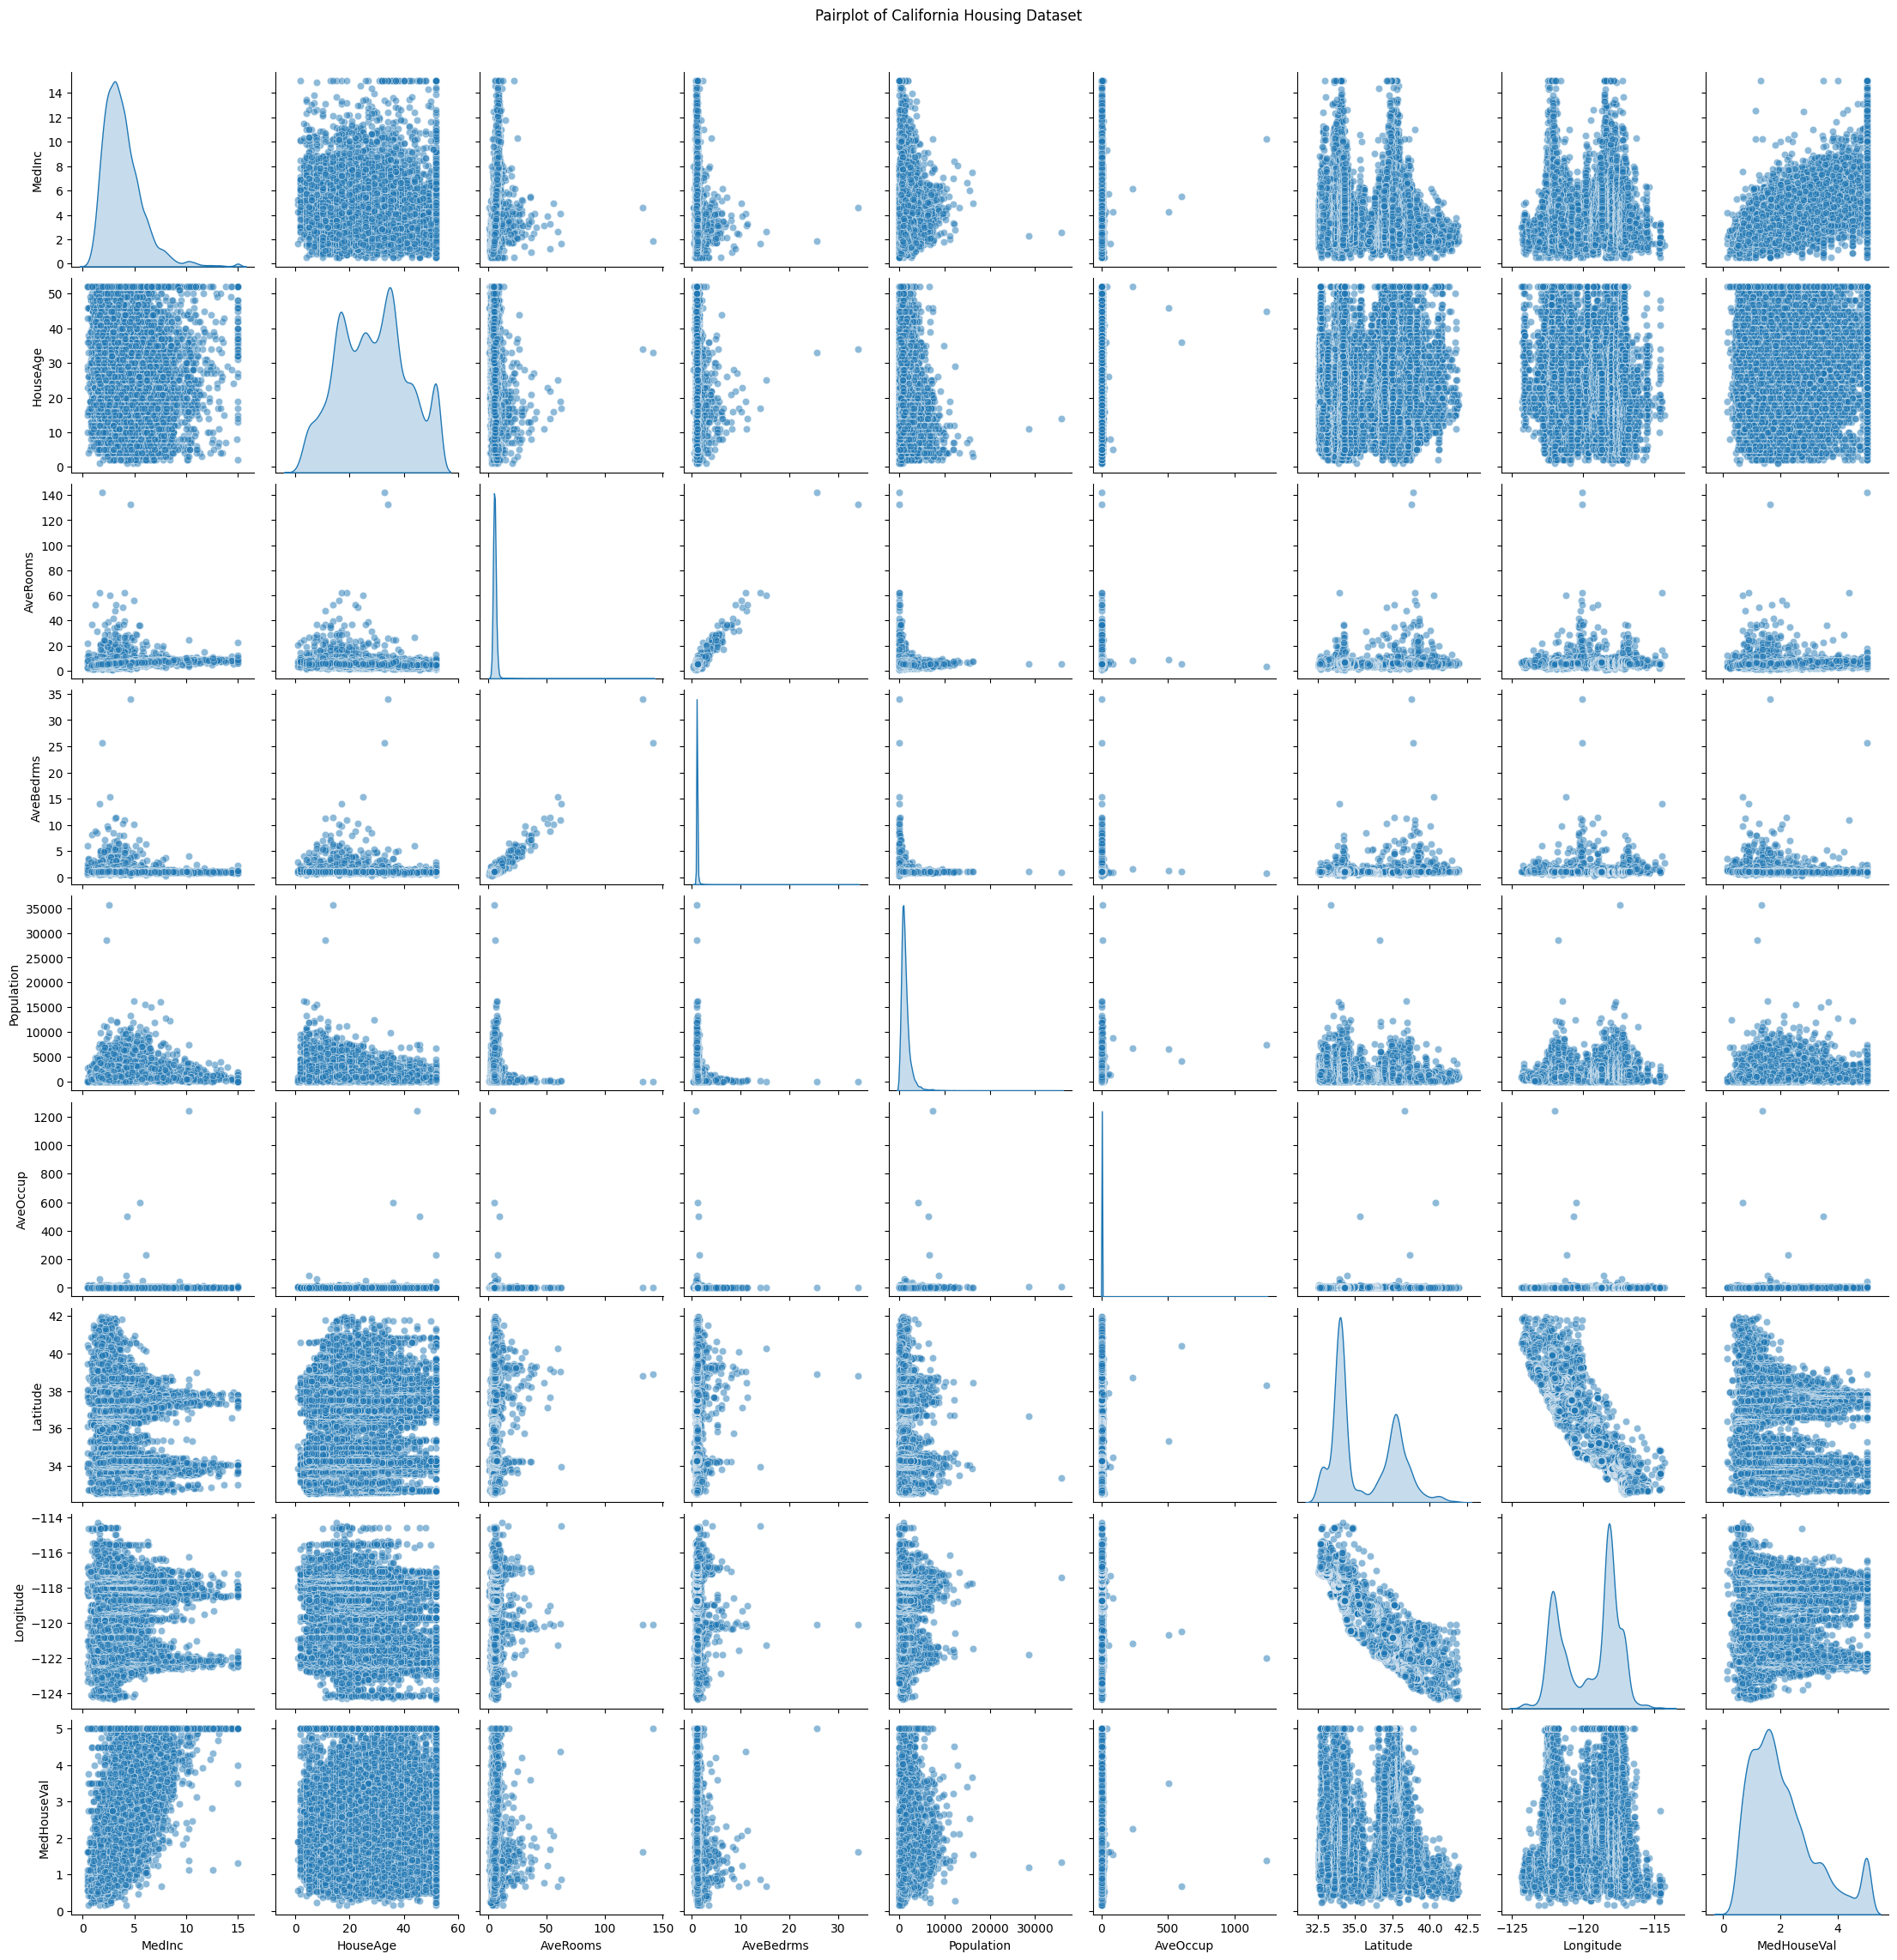

In [4]:
#lab-2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
california_data=fetch_california_housing(as_frame=True)
data=california_data.frame
correlation_matrix=data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='BuPu',fmt='.2f',linewidths=1.5)
plt.title('Correlation Matrix')
plt.show()
sns.pairplot(data,diag_kind='kde',plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of California Housing Dataset',y=1.02)
plt.show()

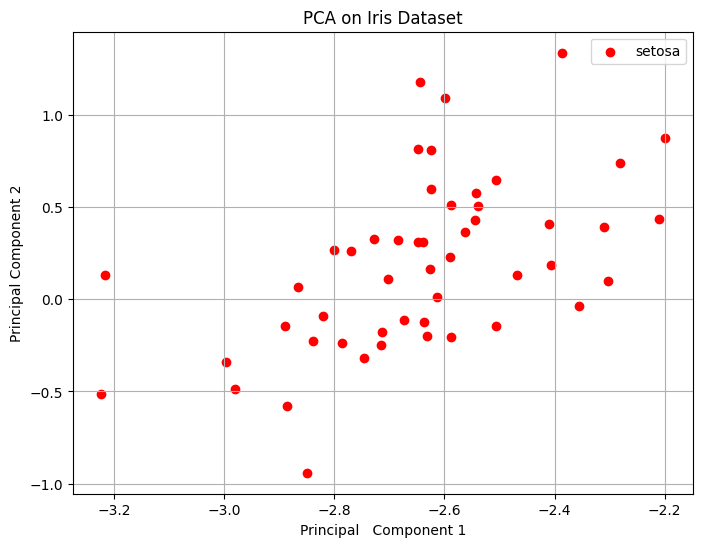

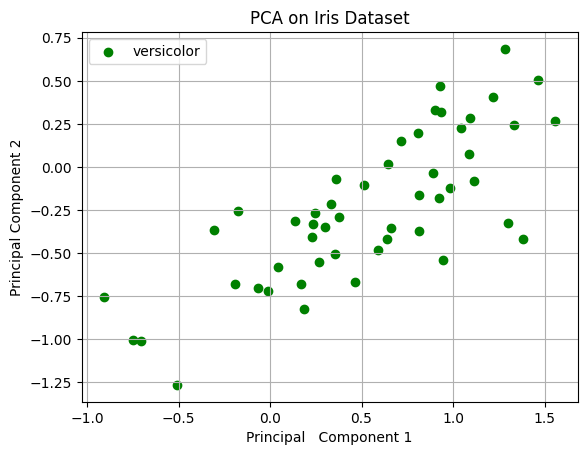

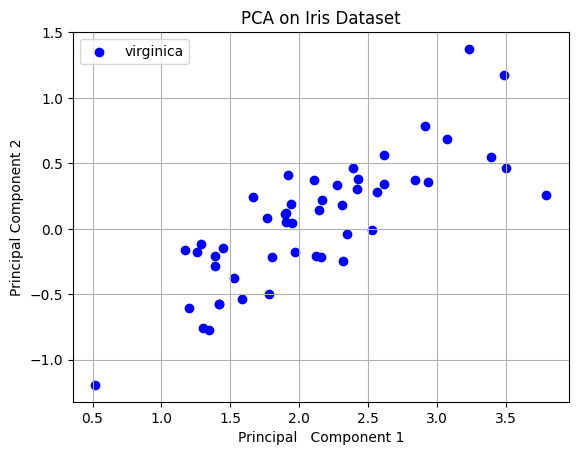

In [1]:
#lab-3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
iris=load_iris()
data=iris.data
labels=iris.target
label_names=iris.target_names

iris_df=pd.DataFrame(data,columns=iris.feature_names)
pca=PCA(n_components=2)
data_reduced=pca.fit_transform(data)
reduced_df=pd.DataFrame(data_reduced,columns=['Principal Component 1','Principal Component 2'])
reduced_df['Label']=labels
plt.figure(figsize=(8,6))
colors=['r','g','b']
for i,label in enumerate(np.unique(labels)):
  plt.scatter(
      reduced_df[reduced_df['Label']==label]['Principal Component 1'],
      reduced_df[reduced_df['Label']==label]['Principal Component 2'],
      label=label_names[label],
      color=colors[i]
  )
  plt.title('PCA on Iris Dataset')
  plt.xlabel('Principal   Component 1')
  plt.ylabel('Principal Component 2')
  plt.legend()
  plt.grid()
  plt.show()



In [1]:
import pandas as pd

# Create sample data for enjoysport.csv
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['yes', 'yes', 'no', 'yes']
}
enjoysport_df = pd.DataFrame(data)

# Save the DataFrame to enjoysport.csv
enjoysport_df.to_csv('enjoysport.csv', index=False)

print("Created 'enjoysport.csv' with sample data.")
print(enjoysport_df.head())

Created 'enjoysport.csv' with sample data.
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        yes
1  Sunny    Warm     High  Strong  Warm     Same        yes
2  Rainy    Cold     High  Strong  Warm   Change         no
3  Sunny    Warm     High  Strong  Cool   Change        yes


In [2]:
#lab-4
import pandas as pd
import numpy as np
data=pd.read_csv('enjoysport.csv')
attribute=np.array(data)[:,:-1]
target=np.array(data)[:,-1]
print("Training data:\n")
print(data)
def train(att,tar):
  for i,val in enumerate(tar):
    if val=='yes':
      specific_h=att[i].copy()
      break
  for i,val in enumerate(att):
    if tar[i]=='yes':
      for x in range(len(specific_h)):
        if val[x]!=specific_h[x]:
          specific_h[x]='?'
        else:
          pass
    return specific_h
print("\n")
print(train(attribute,target))

Training data:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        yes
1  Sunny    Warm     High  Strong  Warm     Same        yes
2  Rainy    Cold     High  Strong  Warm   Change         no
3  Sunny    Warm     High  Strong  Cool   Change        yes


['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']


In [6]:
#lab-5
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
data=np.random.rand(100).reshape(-1,1)
labels=np.array(["Class1" if x<=0.5 else "Class2" for x in data[:50]])
train_data,train_labels=data[:50],labels
test_data=data[50:]
k_values=[1,2,3,4,5,20,30]
for k in k_values:
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(train_data,train_labels)
  predictions=knn.predict(test_data)
  print(f"Predictions for k={k}: \n {predictions}")

#


Predictions for k=1: 
 ['Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class1' 'Class2' 'Class2'
 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2' 'Class2' 'Class2'
 'Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class2' 'Class2' 'Class2'
 'Class2' 'Class2' 'Class1' 'Class2' 'Class2' 'Class2' 'Class2' 'Class2'
 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2'
 'Class2' 'Class2' 'Class1' 'Class1' 'Class2' 'Class2' 'Class1' 'Class2'
 'Class2' 'Class1']
Predictions for k=2: 
 ['Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class1' 'Class1' 'Class2'
 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2' 'Class2' 'Class2'
 'Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class2' 'Class2' 'Class2'
 'Class2' 'Class2' 'Class1' 'Class2' 'Class2' 'Class2' 'Class2' 'Class2'
 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2'
 'Class1' 'Class2' 'Class1' 'Class1' 'Class2' 'Class2' 'Class1' 'Class2'
 'Class2' 'Class1']
Predictions for k=3: 
 ['Class1' 'Clas